## K-Nearest Neighbors (KNN): A Comprehensive Guide for Beginners

This notebook provides a detailed explanation of the K-Nearest Neighbors (KNN) algorithm, covering everything from its fundamental principles to advanced considerations and practical implementation.

-----


### 1\. Introduction to K-Nearest Neighbors (KNN) 🏘️

KNN is one of the simplest and most intuitive non-parametric machine learning algorithms used for both **classification** and **regression** tasks. It's often called a "lazy learner" or "instance-based learning" algorithm because it doesn't build a model during the training phase. Instead, it memorizes the training dataset and performs computations only when a prediction is requested.

**The Core Idea:** "Birds of a feather flock together."

KNN classifies or predicts a new data point based on the majority class or average value of its 'K' most similar (nearest) neighbors in the training data.

-----

### 2\. How KNN Works: The Basic Steps 🚶‍♀️

Let's illustrate with a classification example: Imagine you want to classify a new fruit (e.g., apple or banana) based on its weight and color.

1.  **Choose the Number of Neighbors (K):** This is the most crucial parameter. You decide how many nearest neighbors will influence the prediction. Let's say `K = 3`.

2.  **Calculate Distance:** For a new, unclassified data point, calculate its distance to *every single* data point in the training set. Common distance metrics include:
      * **Euclidean Distance:** The most common. It's the straight-line distance between two points in Euclidean space.
      
      1. For two points $(x_1, y_1)$ and $(x_2, y_2)$ in 2D: $\sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}$
      
      2. For $n$ dimensions: $\sqrt{\sum_{i=1}^{n} (q_i - p_i)^2}$

      
      * **Manhattan Distance (City Block Distance):** Sum of the absolute differences of their Cartesian coordinates.
      
      1. For two points $(x_1, y_1)$ and $(x_2, y_2)$: $|x_2-x_1| + |y_2-y_1|$.
      
      * **Minkowski Distance:** A generalization of Euclidean and Manhattan distances.
      * **Hamming Distance:** For categorical or binary data, counts the positions at which the corresponding symbols are different.

3.  **Find the K Nearest Neighbors:** Select the `K` training data points that have the smallest distances to the new data point.

4.  **Vote (for Classification) / Average (for Regression):**
      * **Classification:** Look at the labels of these `K` nearest neighbors. The new data point is assigned the class that is most frequent among these neighbors (majority vote).
      * **Regression:** The new data point's value is predicted as the average (or weighted average) of the values of its `K` nearest neighbors.

-----

### 3\. Choosing the Optimal K Value 🎯

Selecting the right `K` is critical for KNN's performance.

  * **Small K (e.g., K=1):**
      * Pros: Can capture fine-grained patterns, less bias.
      * Cons: Highly sensitive to noise and outliers in the data. Can lead to overfitting.
  * **Large K:**
      * Pros: More robust to noise, provides smoother decision boundaries, reduces variance.
      * Cons: May smooth out important patterns, can lead to underfitting (high bias). Computationally more expensive.

**Common Strategies for Choosing K:**

1.  **Odd K for Binary Classification:** For binary classification, choosing an odd `K` helps avoid ties in votes.
2.  **Square Root of N:** A common heuristic is to try `K = sqrt(number of training samples)`.
3.  **Cross-Validation:** This is the **most robust method**.
      * Train KNN models with different `K` values (e.g., from 1 to 30) using cross-validation.
      * Evaluate the model's performance (e.g., accuracy for classification, RMSE for regression) for each `K`.
      * Choose the `K` that yields the best performance on the validation sets. This is typically done using `GridSearchCV` or `RandomizedSearchCV` in scikit-learn.
4.  **Domain Knowledge:** Sometimes, understanding the problem or data can give clues about a reasonable `K`.

-----

### 4\. Data Preprocessing for KNN ⚙️

KNN is highly sensitive to the scale and nature of your data. Proper preprocessing is crucial.

1.  **Feature Scaling:**

      * **Why?** KNN calculates distances. If features have different scales (e.g., 'age' in years vs. 'income' in lakhs), the feature with the larger scale will disproportionately influence the distance calculation.
      
      * **Methods:**
          * **Standardization (Z-score normalization):** Transforms data to have a mean of 0 and standard deviation of 1:
          
          $X' = (X - \mu) / \sigma$

          * **Normalization (Min-Max scaling):** Scales data to a fixed range, usually 0 to 1:

          $X' = (X - X_{\text{min}}) / (X_{\text{max}} - X_{\text{min}})$

      * **When:** Always apply scaling to numerical features before using KNN.

2.  **Handling Categorical Features:**

      * KNN works best with numerical data. Categorical features need to be converted.
      * **One-Hot Encoding:** Convert each category into a new binary (0 or 1) feature. This is generally preferred for nominal categories.
      * **Label Encoding:** Convert each category into a unique integer. Use with caution, as it implies an ordinal relationship that might not exist.

3.  **Handling Outliers:**

      * **Why?** KNN is sensitive to outliers because they can significantly distort distance calculations and influence the neighborhood of a query point.
      * **Methods:** Detect and remove or transform outliers if appropriate for your dataset and domain.

4.  **Imputing Missing Values:**

      * KNN cannot directly handle missing values.
      * **Methods:** Impute missing data using strategies like mean, median, mode imputation, or more advanced methods like K-Nearest Neighbor Imputation (which ironically uses KNN to impute missing values\!).

-----

### 5\. Strengths and Weaknesses of KNN 💪📉

**Strengths:**

  * **Simple to Understand and Implement:** The logic is straightforward.
  * **No Training Phase (Lazy Learner):** No explicit model building, making training very fast.
  * **Non-Parametric:** Makes no assumptions about the underlying data distribution, making it flexible for various data types.
  * **Versatile:** Can be used for both classification and regression.
  * **Adaptable:** Can adapt to changing data because it recalculates neighbors for each new query.

**Weaknesses:**

  * **Computationally Expensive (at Prediction Time):** For large datasets, calculating distances to *all* training points for every new prediction can be very slow.
  * **Memory Intensive:** Stores the entire training dataset in memory.
  * **Sensitive to the Curse of Dimensionality:** In high-dimensional spaces, the concept of "distance" becomes less meaningful, and points tend to be equidistant from each other, making neighbor finding unreliable.
  * **Sensitive to Noise and Outliers:** A few noisy points or outliers can drastically change the class of a new data point, especially with small `K`.
  * **Requires Feature Scaling:** Inconsistent feature scales can lead to biased distance calculations.

-----


### 6\. Advanced Concepts & Optimizations 🚀

1.  **Weighted KNN:**

      * Instead of giving equal weight to all `K` neighbors, assign weights based on their distance to the query point. Closer neighbors get higher weights.
      * This can reduce the impact of less relevant neighbors and improve accuracy. Common weighting schemes include `1/distance` or `exp(-distance)`.

2.  **Tree-Based Data Structures (for Faster Queries):**

      * To overcome the computational bottleneck of calculating distances to *all* training points, especially for large datasets, specialized data structures are used.
      * **KD-Trees (k-dimensional trees):** Partitions space with axis-aligned hyperplanes. Efficient for low to moderate dimensions.
      * **Ball Trees:** Divides data into nested hyperspheres. More efficient for high-dimensional data or when data is not axis-aligned.
      * Scikit-learn's `NearestNeighbors` and `KNeighborsClassifier`/`Regressor` can automatically use these structures (`algorithm='auto'`, `'ball_tree'`, `'kd_tree'`).

3.  **Curse of Dimensionality:**

      * As the number of features (dimensions) increases, the volume of the space increases exponentially. Data becomes sparse, and all points tend to be "far" from each other.
      * **Solutions:**
          * **Dimensionality Reduction:** Techniques like Principal Component Analysis (PCA) or t-SNE can reduce the number of features while preserving important information.
          * **Feature Selection:** Select only the most relevant features using methods like Recursive Feature Elimination (RFE) or feature importance from other models.

4.  **Optimizing with Locality Sensitive Hashing (LSH):**

      * For extremely high-dimensional data and massive datasets, LSH is a technique that "hashes" similar items into the same "buckets" with high probability. This allows for approximate nearest neighbor searches much faster than exact methods, though with a trade-off in accuracy.

-----

### 7\. Python Implementation with Scikit-learn 🐍

Let's walk through a simple example using `scikit-learn`.

#### 1. Generate Sample Data

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns


# For Classification (e.g., Iris-like dataset)
from sklearn.datasets import load_iris
iris = load_iris()
X_clf, y_clf = iris.data, iris.target
feature_names_clf = iris.feature_names
class_names_clf = iris.target_names

# For Regression (simple linear relationship with noise)
np.random.seed(42)
X_reg = np.random.rand(100, 1) * 10 # 100 samples, 1 feature
y_reg = (2 * X_reg) + (np.random.randn(100, 1) * 2) + 5 # y = 2x + noise + 5

print("Classification Data Shape (X, y):", X_clf.shape, y_clf.shape)
print("Regression Data Shape (X, y):", X_reg.shape, y_reg.shape)

Classification Data Shape (X, y): (150, 4) (150,)
Regression Data Shape (X, y): (100, 1) (100, 1)


#### 2. Data Splitting

In [ ]:
# Classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=42, stratify=y_clf # stratify for classification
)

# Regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

print("Classification Train/Test Shapes:", X_train_clf.shape, X_test_clf.shape)
print("Regression Train/Test Shapes:", X_train_reg.shape, X_test_reg.shape)

Classification Train/Test Shapes: (105, 4) (45, 4)
Regression Train/Test Shapes: (70, 1) (30, 1)


In [ ]:
X_train_reg[:5]

array([[9.69909852],
       [5.20068021],
       [3.25183322],
       [5.92414569],
       [5.61277198]])

#### 3. Feature Scaling (Crucial for KNN!)

In [ ]:
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf) # Use transform, not fit_transform on test data


scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print("Features Scaled Successfully.")

Features Scaled Successfully.


In [ ]:
X_train_reg_scaled[:5]

array([[ 1.80128424],
       [ 0.18151327],
       [-0.52021911],
       [ 0.44201558],
       [ 0.32989749]])

#### 4. KNN for Classification

In [ ]:
print("--- KNN Classification ---")
# Instantiate the classifier with a chosen K
k_clf = 5 # Example K value
knn_clf = KNeighborsClassifier(n_neighbors=k_clf)

# Train the model
knn_clf.fit(X_train_clf_scaled, y_train_clf)

# Make predictions
y_pred_clf = knn_clf.predict(X_test_clf_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test_clf, y_pred_clf)
print(f"KNeighborsClassifier (K={k_clf}) Accuracy: {accuracy:.4f}")

--- KNN Classification ---
KNeighborsClassifier (K=5) Accuracy: 0.9111


#### 5. KNN for Regression

In [ ]:
print("\n--- KNN Regression ---")
# Instantiate the regressor with a chosen K
k_reg = 5 # Example K value
knn_reg = KNeighborsRegressor(n_neighbors=k_reg)

# Train the model
knn_reg.fit(X_train_reg_scaled, y_train_reg)

# Make predictions
y_pred_reg = knn_reg.predict(X_test_reg_scaled)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
print(f"KNeighborsRegressor (K={k_reg}) RMSE: {rmse:.4f}")


--- KNN Regression ---
KNeighborsRegressor (K=5) RMSE: 1.7695


#### 6. Finding Optimal K using GridSearchCV (Classification Example)

In [ ]:

print("--- Finding Optimal K with GridSearchCV (Classification) ---")
# Define a range of K values to test
param_grid = {'n_neighbors': np.arange(1, 31)} # Test K from 1 to 30

# Create a GridSearchCV object
grid_search_clf = GridSearchCV(
    KNeighborsClassifier(), # Estimator
    param_grid,             # Parameters to search
    cv=5,                   # 5-fold cross-validation
    scoring='accuracy',     # Metric to optimize
    n_jobs=-1               # Use all available CPU cores
)

# Fit GridSearchCV to the scaled training data
grid_search_clf.fit(X_train_clf_scaled, y_train_clf)

print(f"Best K for Classification: {grid_search_clf.best_params_['n_neighbors']}")
print(f"Best Cross-Validation Accuracy: {grid_search_clf.best_score_:.4f}")

# You can now use the best estimator found by GridSearchCV
best_knn_clf = grid_search_clf.best_estimator_
y_pred_best_clf = best_knn_clf.predict(X_test_clf_scaled)
final_accuracy = accuracy_score(y_test_clf, y_pred_best_clf)
print(f"Test Accuracy with Optimal K: {final_accuracy:.4f}")

--- Finding Optimal K with GridSearchCV (Classification) ---
Best K for Classification: 14
Best Cross-Validation Accuracy: 0.9714
Test Accuracy with Optimal K: 0.9556


#### 7. Visualization of K vs. Performance (Classification Example)

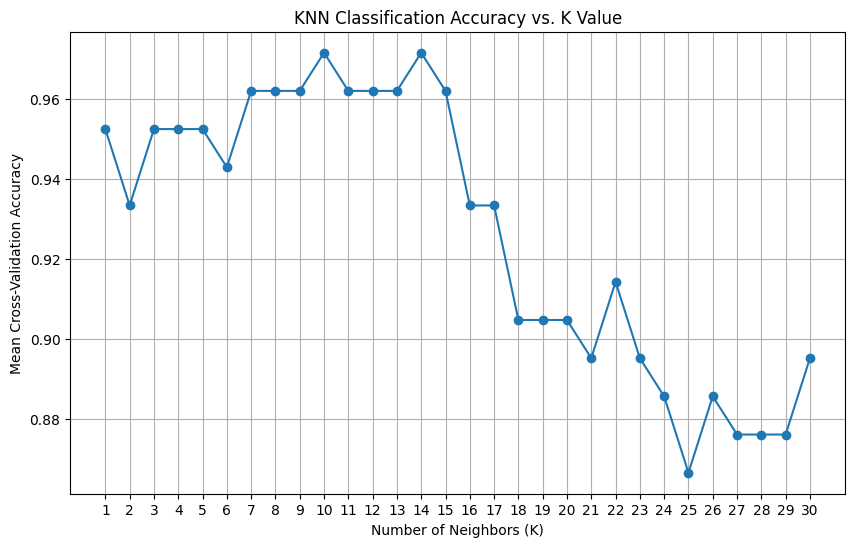

In [ ]:
# Get mean test scores for each K from GridSearchCV results
results = pd.DataFrame(grid_search_clf.cv_results_)
k_values = results['param_n_neighbors']
mean_test_scores = results['mean_test_score']

plt.figure(figsize=(10, 6))
plt.plot(k_values, mean_test_scores, marker='o', linestyle='-')
plt.title('KNN Classification Accuracy vs. K Value')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

#### 8. Weighted KNN Example (Classification)

In [ ]:
# prompt: Explain KNeighborsClassifier(n_neighbors=best_knn_clf.n_neighbors, weights='distance')

print("\n--- Weighted KNN Classification ---")
# Instantiate the classifier with optimal K and weights='distance'
# 'weights='distance'' means closer neighbors have a greater influence
# This is the model that achieved the best performance based on GridSearchCV
weighted_knn_clf = KNeighborsClassifier(n_neighbors=best_knn_clf.n_neighbors, weights='distance')

# Train the model
weighted_knn_clf.fit(X_train_clf_scaled, y_train_clf)

# Make predictions
y_pred_weighted_clf = weighted_knn_clf.predict(X_test_clf_scaled)

# Evaluate the model
accuracy_weighted = accuracy_score(y_test_clf, y_pred_weighted_clf)
print(f"Weighted KNeighborsClassifier (K={weighted_knn_clf.n_neighbors}) Accuracy: {accuracy_weighted:.4f}")

# Compare with the unweighted best model accuracy
print(f"Unweighted KNeighborsClassifier (K={best_knn_clf.n_neighbors}) Test Accuracy: {final_accuracy:.4f}")

# Explanation of KNeighborsClassifier(n_neighbors=best_knn_clf.n_neighbors, weights='distance'):
# - KNeighborsClassifier: This is the scikit-learn class for implementing the K-Nearest Neighbors algorithm.
# - n_neighbors=best_knn_clf.n_neighbors: This parameter sets the number of neighbors (K) to consider when making a prediction.
#   We are using the value of n_neighbors that was determined to be optimal by the GridSearchCV process (stored in best_knn_clf.n_neighbors).
# - weights='distance': This parameter specifies how the votes of the neighbors are weighted.
#   When set to 'distance', the contribution of each neighbor to the prediction is inversely proportional to its distance from the query point.
#   Closer neighbors have a larger influence on the prediction than neighbors that are farther away.
#   The default weight is 'uniform', where all K neighbors have equal influence regardless of distance.
# This line of code creates a KNN classifier instance that uses the best number of neighbors found via cross-validation and weights the influence of those neighbors based on how close they are to the point being classified.



--- Weighted KNN Classification ---
Weighted KNeighborsClassifier (K=14) Accuracy: 0.9556
Unweighted KNeighborsClassifier (K=14) Test Accuracy: 0.9556


In [ ]:
print("\n--- Weighted KNN Classification ---")
# Instantiate KNeighborsClassifier with weights='distance'
# This means closer neighbors have a greater influence
knn_clf_weighted = KNeighborsClassifier(n_neighbors=best_knn_clf.n_neighbors, weights='distance')
knn_clf_weighted.fit(X_train_clf_scaled, y_train_clf)
y_pred_weighted_clf = knn_clf_weighted.predict(X_test_clf_scaled)
accuracy_weighted = accuracy_score(y_test_clf, y_pred_weighted_clf)
print(f"Weighted KNeighborsClassifier (K={best_knn_clf.n_neighbors}) Accuracy: {accuracy_weighted:.4f}")


--- Weighted KNN Classification ---
Weighted KNeighborsClassifier (K=14) Accuracy: 0.9556


### 8\. Logical Understanding

#### K-Nearest Neighbors (KNN): A Classification Example

Imagine you have some fruits, and you want to classify a new, unknown fruit. You have data for two types of fruits: **Apples** 🍎 and **Bananas** 🍌, based on two characteristics: **Sweetness** and **Crunchiness**.

Here are your existing data points:

| Fruit Type | Sweetness | Crunchiness |
| :--------: | :-------: | :---------: |
|   Apple    |     7     |      8      |
|   Apple    |     6     |      7      |
|   Banana   |     9     |      2      |
|   Banana   |     8     |      3      |

Now, you find a **New Fruit** with:
* **Sweetness:** 7.5
* **Crunchiness:** 5

You want to know if this New Fruit is an Apple or a Banana. This is where KNN comes in.

---

### Step 1: Choose Your 'K' Value 🎯

**K** is the number of nearest neighbors you'll look at to make your decision. Let's pick a small, odd number to avoid ties for now:

* **Let's choose K = 3.**

---

### Step 2: Calculate Distances to All Existing Points 📏

We need to figure out how "close" our New Fruit is to each of the existing fruits. The most common way to do this is using **Euclidean Distance**.

The formula for Euclidean Distance between two points $(x_1, y_1)$ and $(x_2, y_2)$ is:
$\sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}$

Let's calculate the distance for our New Fruit (Sweetness 7.5, Crunchiness 5):

1.  **To Apple 1 (7, 8):**
    Distance = $\sqrt{(7.5 - 7)^2 + (5 - 8)^2}$
    = $\sqrt{(0.5)^2 + (-3)^2}$
    = $\sqrt{0.25 + 9}$
    = $\sqrt{9.25}$ $\approx$ **3.04**

2.  **To Apple 2 (6, 7):**
    Distance = $\sqrt{(7.5 - 6)^2 + (5 - 7)^2}$
    = $\sqrt{(1.5)^2 + (-2)^2}$
    = $\sqrt{2.25 + 4}$
    = $\sqrt{6.25}$ = **2.50**

3.  **To Banana 1 (9, 2):**
    Distance = $\sqrt{(7.5 - 9)^2 + (5 - 2)^2}$
    = $\sqrt{(-1.5)^2 + (3)^2}$
    = $\sqrt{2.25 + 9}$
    = $\sqrt{11.25}$ $\approx$ **3.35**

4.  **To Banana 2 (8, 3):**
    Distance = $\sqrt{(7.5 - 8)^2 + (5 - 3)^2}$
    = $\sqrt{(-0.5)^2 + (2)^2}$
    = $\sqrt{0.25 + 4}$
    = $\sqrt{4.25}$ $\approx$ **2.06**

---

### Step 3: Find the K Nearest Neighbors 🤏

Now, we list the distances from smallest to largest and pick the top **K=3** closest ones:

1.  Banana 2: 2.06
2.  Apple 2: 2.50
3.  Apple 1: 3.04
4.  Banana 1: 3.35

Our 3 nearest neighbors are:
* **Banana 2**
* **Apple 2**
* **Apple 1**

---

### Step 4: Vote for Classification 🗳️

Look at the fruit types of our 3 nearest neighbors:

* Banana 2 is a **Banana**
* Apple 2 is an **Apple**
* Apple 1 is an **Apple**

Among these three, we have:
* **2 votes for Apple** 🍎
* **1 vote for Banana** 🍌

Since "Apple" has the majority vote (2 out of 3), the **New Fruit is classified as an Apple!**

---

## What if it was Regression? 📉

If this were a regression problem (e.g., predicting a numerical "Sweetness Score" instead of a fruit type), Step 4 would be different:

* You would take the **average** of the Sweetness Scores of the 3 nearest neighbors.
* For instance, if Banana 2 had a score of 8, Apple 2 a score of 7, and Apple 1 a score of 6, the prediction for the New Fruit would be $(8 + 7 + 6) / 3 = 7$.

That's the essence of KNN! It's simple, intuitive, and effective for many tasks, especially when you have good features that represent similarity well.

#### K-Nearest Neighbors (KNN): A Regression Example

Imagine you're a real estate agent trying to estimate the **price** of a new house that just came on the market. You have data from a few recently sold houses in the same neighborhood, with their **Size (in sq ft)** and **Number of Bedrooms**.

Here's your existing data for recently sold houses:

| House ID | Size (sq ft) | Bedrooms | Price (in Lakhs) |
| :------: | :----------: | :------: | :--------------: |
|    1     |     1000     |    2     |       45         |
|    2     |     1200     |    3     |       55         |
|    3     |     800      |    2     |       38         |
|    4     |     1500     |    4     |       68         |
|    5     |     950      |    2     |       42         |

Now, you have a **New House** that just listed:
* **Size (sq ft):** 1100
* **Bedrooms:** 3

You want to predict its **Price**. This is a regression problem because the target (Price) is a continuous numerical value.

---

### Step 1: Choose Your 'K' Value 🎯

As before, **K** is the number of nearest neighbors we'll consider.

* **Let's choose K = 3.**

---

### Step 2: Calculate Distances to All Existing Points 📏

We'll use **Euclidean Distance** to find how similar the New House is to each of the recently sold houses.

The formula for Euclidean Distance between two points $(x_1, y_1)$ and $(x_2, y_2)$ is:
$\sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}$

For our New House (Size 1100, Bedrooms 3):

1.  **To House 1 (Size 1000, Bedrooms 2):**
    Distance = $\sqrt{(1100 - 1000)^2 + (3 - 2)^2}$
    = $\sqrt{(100)^2 + (1)^2}$
    = $\sqrt{10000 + 1}$
    = $\sqrt{10001}$ $\approx$ **100.005**

2.  **To House 2 (Size 1200, Bedrooms 3):**
    Distance = $\sqrt{(1100 - 1200)^2 + (3 - 3)^2}$
    = $\sqrt{(-100)^2 + (0)^2}$
    = $\sqrt{10000 + 0}$
    = $\sqrt{10000}$ = **100.000**

3.  **To House 3 (Size 800, Bedrooms 2):**
    Distance = $\sqrt{(1100 - 800)^2 + (3 - 2)^2}$
    = $\sqrt{(300)^2 + (1)^2}$
    = $\sqrt{90000 + 1}$
    = $\sqrt{90001}$ $\approx$ **300.002**

4.  **To House 4 (Size 1500, Bedrooms 4):**
    Distance = $\sqrt{(1100 - 1500)^2 + (3 - 4)^2}$
    = $\sqrt{(-400)^2 + (-1)^2}$
    = $\sqrt{160000 + 1}$
    = $\sqrt{160001}$ $\approx$ **400.001**

5.  **To House 5 (Size 950, Bedrooms 2):**
    Distance = $\sqrt{(1100 - 950)^2 + (3 - 2)^2}$
    = $\sqrt{(150)^2 + (1)^2}$
    = $\sqrt{22500 + 1}$
    = $\sqrt{22501}$ $\approx$ **150.003**

---

### **Important Note on Scaling:**
Did you notice something about the distances? The "Size" feature (which has values in hundreds or thousands) completely **dominates** the distance calculation compared to "Bedrooms" (which has small single-digit values). A difference of 100 sq ft makes a much bigger impact than a difference of 1 bedroom.

For real-world KNN, it's **crucial to perform Feature Scaling** (e.g., Standardization or Normalization) on your numerical features *before* calculating distances. This ensures all features contribute proportionally to the similarity measure. For this illustrative example, we skipped scaling to keep the raw numbers simple, but always remember it for actual applications!

---

### Step 3: Find the K Nearest Neighbors 🤏

Now, we sort the calculated distances from smallest to largest and pick the top **K=3** closest houses:

1.  House 2: 100.000 (Price: 55 Lakhs)
2.  House 1: 100.005 (Price: 45 Lakhs)
3.  House 5: 150.003 (Price: 42 Lakhs)
4.  House 3: 300.002
5.  House 4: 400.001

Our 3 nearest neighbors are:
* **House 2** (Price: 55 Lakhs)
* **House 1** (Price: 45 Lakhs)
* **House 5** (Price: 42 Lakhs)

---

### Step 4: Calculate the Average for Regression 💲

For regression, instead of voting for a class, we take the **average** of the target values (Prices) of our K nearest neighbors.

* Price of House 2 = 55 Lakhs
* Price of House 1 = 45 Lakhs
* Price of House 5 = 42 Lakhs

Average Price = $(55 + 45 + 42) / 3$
= $142 / 3$
$\approx$ **47.33 Lakhs**

Therefore, based on our KNN model with K=3, the predicted price for the New House is approximately **47.33 Lakhs**.

---

This detailed example shows how KNN leverages the similarity between data points to predict a continuous numerical value by averaging the target values of its closest neighbors.

### 9\.Lazy Learner

KNN is called a **lazy learner** because it doesn't build a complex model during the `fit` (training) phase. Instead, the `fit` method in scikit-learn's `KNeighborsClassifier` is doing something very simple yet crucial:

The `fit` method for KNN is primarily **memorizing and storing the training data** (`X_train_clf_scaled` and `y_train_clf`). It doesn't learn weights, coefficients, or decision rules like other algorithms (e.g., Logistic Regression, Decision Trees, XGBoost). It just makes the training data readily available for when predictions are needed.



---

#### What `fit` Does for KNN

1.  **Stores the Training Data:** The most important task is to store `X_train_clf_scaled` (the features of your training samples) and `y_train_clf` (the corresponding labels/targets). When you call `predict` later, the algorithm needs to compare new data points to these stored training examples.

2.  **Performs Minimal Pre-processing (Optional, based on `algorithm`):** Depending on the `algorithm` parameter you choose (e.g., 'auto', 'brute', 'kd_tree', 'ball_tree'), the `fit` method might also:
    * **Build Data Structures:** If 'kd_tree' or 'ball_tree' is specified (or 'auto' decides to use them for efficiency), `fit` will build these specialized tree-like data structures. These structures don't represent a "learned model" in the traditional sense, but rather an optimized way to quickly find the nearest neighbors in high-dimensional space during prediction, instead of having to calculate distances to *every* single point from scratch each time.
    * **Check Data Consistency:** It might perform basic checks to ensure the input data is in a valid format.

Essentially, `fit` for KNN is like creating an organized library of all your known books (training data). It doesn't read the books and summarize them (that's like building a model); it just puts them on shelves in a way that makes it easy to find similar books quickly when a new book comes in (during prediction).



---

####  Why "Lazy" Learner?

The "lazy" moniker comes from the fact that **all the "learning" (i.e., the intensive computation of distances and aggregation of neighbor information) happens at the time of prediction**, not during training. In contrast, an "eager" learner like a Decision Tree or a Neural Network spends a lot of time during `fit` to build a complex internal model that can then make very fast predictions without re-examining the original training data.

### 10.Conclusion ✨

KNN is a powerful and versatile algorithm that's easy to grasp. While it boasts simplicity and adaptability, its performance heavily relies on proper data preprocessing (especially scaling) and careful selection of the `K` parameter. Understanding its strengths and weaknesses, along with optimization techniques like using tree-based data structures and handling dimensionality, will enable you to effectively apply KNN to a wide range of machine learning problems.

### 11.Additional Resources ✨

#### Example

In [ ]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# Load Iris Dataset
iris = load_iris()
X = iris.data
y = iris.target


In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Initialize KNN with k=3
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

# Predict
y_pred = knn.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



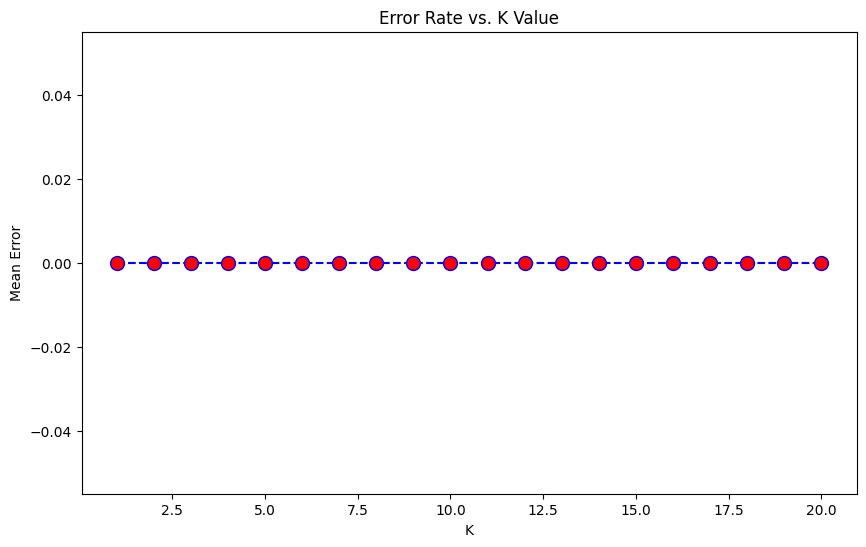

In [ ]:
error_rates = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred_k = knn.predict(X_test_scaled)
    error = np.mean(pred_k != y_test)
    error_rates.append(error)

# Plot Error Rates
plt.figure(figsize=(10,6))
plt.plot(range(1,21), error_rates, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Mean Error')
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error

# Create synthetic regression data
X_reg, y_reg = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Train KNN Regressor
knn_reg = KNeighborsRegressor(n_neighbors=3)
knn_reg.fit(X_train_reg, y_train_reg)
y_pred_reg = knn_reg.predict(X_test_reg)

# Evaluation
print("MSE:", mean_squared_error(y_test_reg, y_pred_reg))

MSE: 128.82204336272395


In [ ]:
### Distance Metrics
"""
- Euclidean (default)
- Manhattan
- Minkowski (generalized)
"""

knn_manhattan = KNeighborsClassifier(n_neighbors=3, metric='manhattan')
knn_manhattan.fit(X_train_scaled, y_train)
y_pred_manhattan = knn_manhattan.predict(X_test_scaled)
print("Accuracy with Manhattan Distance:", accuracy_score(y_test, y_pred_manhattan))

### Weighted KNN
knn_weighted = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn_weighted.fit(X_train_scaled, y_train)
y_pred_weighted = knn_weighted.predict(X_test_scaled)
print("Accuracy with Weighted KNN:", accuracy_score(y_test, y_pred_weighted))

### KDTree & BallTree (for large datasets)
from sklearn.neighbors import KDTree, BallTree

# KDTree for fast neighbor search
kd_tree = KDTree(X_train_scaled)
dist, ind = kd_tree.query(X_test_scaled, k=3)
print("KDTree Neighbors (Indices):\n", ind)
print("Accuracy with KDTree KNN:", accuracy_score(y_test, ind.max(axis=1)))

### Using GridSearchCV for Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': range(1, 21),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_knn.fit(X_train_scaled, y_train)
print("Best Parameters:", grid_knn.best_params_)


Accuracy with Manhattan Distance: 1.0
Accuracy with Weighted KNN: 1.0
KDTree Neighbors (Indices):
 [[ 79  39 115]
 [ 48  14  13]
 [ 24 106  21]
 [ 79  90  86]
 [ 92  80  18]
 [114  26   7]
 [ 95  20 108]
 [ 85 103  61]
 [110  68  73]
 [118  25 108]
 [ 83  17  87]
 [104  55  32]
 [114   7  26]
 [ 55 104  32]
 [ 84  98  28]
 [  6  11  59]
 [ 76  87 103]
 [ 53  65  15]
 [108  20  34]
 [ 50  87 107]
 [ 38  78  70]
 [ 42 113  81]
 [ 57  33  35]
 [ 50 107  87]
 [ 37  19  69]
 [ 76 103  85]
 [ 50   5  73]
 [ 61 103  97]
 [104  55  32]
 [ 55  70 104]]
Accuracy with KDTree KNN: 0.0
Best Parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}


#### Minkowski Distance

![](https://media.licdn.com/dms/image/v2/D4E22AQGqB3HYk_Izzw/feedshare-shrink_800/feedshare-shrink_800/0/1692458492178?e=1756339200&v=beta&t=r9Rhv9Icq2RoAq60Bv-cDGlIa-zuDdgXEMk-yVsgEDc)

[Minkowski Distance](https://www.linkedin.com/posts/mehdihamedi_dataanalysis-machinelearning-mathematics-activity-7098685430295879680-U5jl/)

#### Feature Scaling

![](https://datasciencedojo.com/wp-content/uploads/feature-scaling-techniques-1.webp)

[Feature Scaling in ML](https://www.appliedaicourse.com/blog/feature-scaling-in-machine-learning/)

[Feature Scaling](https://datasciencedojo.com/blog/feature-scaling/)

#### What is the Curse of Dimensionality?

The **Curse of Dimensionality** refers to various phenomena that arise when dealing with high-dimensional data.
As the number of features or dimensions increases, the volume of the feature space grows exponentially, leading to sparsity in the data distribution.
This sparsity can result in several challenges such as increased computational complexity, overfitting, and deteriorating performance of certain algorithms.

**How does Dimensionality effect KNN Performance?**
The impact of dimensionality on the performance of KNN (K-Nearest Neighbors) is a well-known issue in machine learning. Here's a breakdown of how dimensionality affects KNN performance:

* **Increased Sparsity**: As the number of dimensions increases, the volume of the space grows exponentially. Consequently, the available data becomes sparser, meaning that data points are spread farther apart from each other. This sparsity can lead to difficulties in finding meaningful nearest neighbors, as there may be fewer neighboring points within a given distance.
* **Equal Distances**: In high-dimensional spaces, the concept of distance becomes less meaningful. As the number of dimensions increases, the distance between any two points tends to become more uniform, or equidistant. This phenomenon occurs because the influence of any single dimension diminishes as the number of dimensions grows, leading to points being distributed more uniformly across the space.
* **Degraded Performance**: KNN relies on the assumption that nearby points in the feature space are likely to have similar labels. However, in high-dimensional spaces, this assumption may no longer hold true due to the increased sparsity and equalization of distances. As a result, KNN may struggle to accurately classify data points, leading to degraded performance.
* **Increased Computational Complexity**: With higher dimensionality, the computational cost of KNN increases significantly. The algorithm needs to compute distances in a high-dimensional space, which involves more calculations. This can make the KNN algorithm slower and less efficient, especially when dealing with large datasets.

**How to reduce Dimensionality?**
Dimensionality reduction techniques aim to mitigate the curse of dimensionality by reducing the number of features while preserving the most relevant information.

* **Principal Component Analysis (PCA)**: PCA is a technique used to reduce the dimensionality of the data by projecting it onto a lower-dimensional subspace while preserving the maximum variance. It achieves this by finding the principal components, which are orthogonal directions in the feature space that capture the most variance in the data.
* **Linear Discriminant Analysis (LDA)**: LDA is a supervised dimensionality reduction technique that aims to find the linear combinations of features that best separate different classes in the data. Unlike PCA, which focuses on maximizing variance, LDA focuses on maximizing the between-class scatter while minimizing the within-class scatter. LDA projects the data onto a lower-dimensional space that maximizes class separability.
Both PCA and LDA can be used as preprocessing steps before applying KNN or other machine learning algorithms to reduce the dimensionality of the data and improve the performance of the models.